```bash
=============================================================================  
STAGE 1 — AIR MODELLING ATTRIBUTION  
Gaussian Plume Transport Matrix → Classical & Bayesian Source Inversion  
Model: C = T · Q  
  C  (n_stations,)       — observed concentration vector  [µg/m³]  
  T  (n_stations, n_src) — transport matrix (Gaussian Plume)  [µg/m³ per g/s]  
  Q  (n_src,)            — unknown emission rates  [g/s]  
References:  
  Seinfeld & Pandis, "Atmospheric Chemistry and Physics", 3rd ed., 2016  
  Pasquill & Smith, "Atmospheric Diffusion", 3rd ed., 1983  
  Turner, "Workbook of Atmospheric Dispersion Estimates", EPA, 1970  
=============================================================================  
```

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import sympy as sp
from sympy import (
    symbols,
    exp,
    pi,
    sqrt,
    latex,
    simplify,
    Rational,
    cos,
    sin,
    atan2,
    Piecewise,
    Function,
    Matrix,
    init_printing,
)
# Display settings
pd.set_option("display.float_format", "{:.4f}".format)
np.set_printoptions(precision=4, suppress=True)

In [2]:
POLLUTANT = "pm25"          # change to pm10, no2, etc. to explore
H_STACK   = 20.0            # effective stack / emission height [m]
# 20 m is a reasonable proxy for a monitoring station
# in a mixed urban environment (road + industry blend)
ROOT_DIR = Path().resolve().parents[2]
DATA_DIR = ROOT_DIR / "backend" / "data"
MASTER_DATASET_FILE  = DATA_DIR / "artifacts" / "final_master_dataset.csv"
STATIONS_FILE = DATA_DIR / "raw" / "stations.csv"
stations_df = pd.read_csv(STATIONS_FILE)

In [17]:
stations_df.head(5)

,SlNo,StationName,Organization,Latitude,Longitude,SiteID
0,1,BTMLayout,CPCB,12.9135,77.5951,162
1,2,BWSSBKadabesanahalli,CPCB,12.9352,77.6814,164
2,3,BapujiNagar,KSPCB,12.9519,77.5398,1553
3,4,CityRailwayStation,KSPCB,12.9757,77.5661,165
4,5,Hebbal,KSPCB,13.0292,77.5859,1554


In [3]:
STATION_NAMES = list(stations_df.StationName)
STATION_NAMES

['BTMLayout',
 'BWSSBKadabesanahalli',
 'BapujiNagar',
 'CityRailwayStation',
 'Hebbal',
 'HombegowdaNagar',
 'Jayanagar5thBlock',
 'Jigani',
 'KasturiNagar',
 'Peenya',
 'RVCE-Mailasandra',
 'SaneguravaHalli',
 'Shivapura_Peenya',
 'SilkBoard']

In [4]:
from IPython.display import display
# Block 1 — LOAD DATA (with graceful synthetic fallback)
print("\n Block 1 : Loading data ")
N = len(STATION_NAMES)  # 14
print(f"  Loading from {MASTER_DATASET_FILE}")
df_full = pd.read_csv(MASTER_DATASET_FILE, parse_dates=["time"])
df_full = df_full[df_full["station_name"].isin(STATION_NAMES)]
display(df_full.head(3))
display(df_full.dtypes)


 Block 1 : Loading data 
  Loading from /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/final_master_dataset.csv


,time,pm25,pm10,no,no2,nox,nh3,so2,co,o3,...,wind_direction,rainfall,total_rainfall,solar_radiation,pressure,station_name,site,org,latitude,longitude
0,2025-01-01 00:00:00,36.0000,90.0000,3.1000,11.8000,9.8000,5.0000,4.5000,500.0000,33.3000,...,114.0000,0.0000,0.0000,NaN,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398
1,2025-01-01 00:15:00,36.0000,90.0000,3.2000,12.4000,10.2000,5.3000,4.6000,480.0000,35.5000,...,112.0000,0.0000,0.0000,NaN,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398
2,2025-01-01 00:30:00,36.0000,90.0000,3.2000,11.3000,9.6000,5.0000,4.7000,560.0000,33.6000,...,117.0000,0.0000,0.0000,NaN,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398


time                   datetime64[us]
pm25                          float64
pm10                          float64
no                            float64
no2                           float64
nox                           float64
nh3                           float64
so2                           float64
co                            float64
o3                            float64
benzene                       float64
toluene                       float64
ethyl_benzene                 float64
mp_xylene                     float64
average_temperature           float64
relative_humidity             float64
wind_speed                    float64
wind_direction                float64
rainfall                      float64
total_rainfall                float64
solar_radiation               float64
pressure                      float64
station_name                      str
site                            int64
org                               str
latitude                      float64
longitude   

# 1. Select a specific timestamp

In [5]:
# Pick a representative single time window: median wind conditions per station
# then take the earliest time where all 14 stations have valid data
pivot_check = df_full.dropna(
    subset=[
        POLLUTANT,
        "wind_speed",
        "wind_direction",
    ]  # Removes rows where any of these are missing
).pivot_table(index="time", columns="station_name", values=POLLUTANT, aggfunc="first")
print("Pivoted table :")
display(pivot_check.head(3))

full_rows = pivot_check.dropna(
    axis=0
)  # Keep only times where: all 14 stations have pollutant data
# Select the most recent time
if len(full_rows) > 0:
    t0 = full_rows.index[0]
else:
    t0 = df_full["time"].min()
print(f"Selected snapshot time: {t0}")

snap = df_full[df_full["time"] == t0].set_index("station_name")
C_obs = np.array(
    [snap.loc[s, POLLUTANT] if s in snap.index else np.nan for s in STATION_NAMES],
    dtype=float,
)
WS = np.array(
    [snap.loc[s, "wind_speed"] if s in snap.index else 2.5 for s in STATION_NAMES],
    dtype=float,
)
WD = np.array(
    [
        snap.loc[s, "wind_direction"] if s in snap.index else 200.0
        for s in STATION_NAMES
    ],
    dtype=float,
)
SR = np.array(
    [
        snap.loc[s, "solar_radiation"] if s in snap.index else 200.0
        for s in STATION_NAMES
    ],
    dtype=float,
)
hour = t0.hour

# Fill any remaining NaNs with column medians
C_obs = np.where(np.isnan(C_obs), np.nanmedian(C_obs), C_obs)
WS = np.where(np.isnan(WS), 2.5, WS)
WD = np.where(np.isnan(WD), 200.0, WD)
SR = np.where(np.isnan(SR), 200.0, SR)


print(f"{'Stations':<20}: {N}")
print(f"{'Pollutant':<20}: {POLLUTANT}")
print(f"{'Wind speed range':<20}: {WS.min():.2f} - {WS.max():.2f} m/s")
print(f"{'Wind dir range':<20}: {WD.min():.1f}° - {WD.max():.1f}°")

Pivoted table :


station_name,Hebbal,Jigani,KasturiNagar,SilkBoard
time,,,,
2025-01-01 00:00:00,62.0000,71.1600,32.9900,57.0000
2025-01-01 00:15:00,62.0000,71.1600,32.9900,57.0000
2025-01-01 00:30:00,62.0000,71.1600,32.9900,57.0000


Selected snapshot time: 2025-01-01 00:00:00
Stations            : 14
Pollutant           : pm25
Wind speed range    : 0.03 - 5.50 m/s
Wind dir range      : 42.5° - 200.0°


In [6]:
lats = np.array(stations_df.Latitude)
lons = np.array(stations_df.Longitude)
print("Latitude",lats)
print("Longitude",lons)

Latitude [12.9135 12.9352 12.9519 12.9757 13.0292 12.9385 12.921  12.7816 13.0039
 13.027  12.9214 12.9903 13.0246 12.9173]
Longitude [77.5951 77.6814 77.5398 77.5661 77.5859 77.5901 77.5849 77.6299 77.6642
 77.4941 77.5025 77.5431 77.508  77.6228]


# 2. Gaussian Plume Model  

In [7]:
from IPython.display import display, Math

# Block 2 — SYMPY: THE GAUSSIAN PLUME MODEL
print("\n Block 2 : Gaussian Plume Model — symbolic derivation ")

# --- 2.1  Symbol definitions -------------------------------------------------
x, y, z, H, u = symbols("x y z H u", positive=True)
sigma_y, sigma_z = symbols("sigma_y sigma_z", positive=True)
Q_src = symbols("Q", positive=True)  # emission rate [g/s]
a_y, b_y = symbols("a_y b_y", positive=True)
a_z, b_z = symbols("a_z b_z", positive=True)

# --- 2.2  Full 3-D Gaussian plume (with ground reflection) ------------------
#   The steady-state solution to the advection-diffusion equation for a
#   continuous point source at height H above ground, assuming:
#     • Uniform mean wind u in the x-direction
#     • Gaussian spreading in y (crosswind) and z (vertical)
#     • Perfectly reflecting ground (image source trick)
#   C(x,y,z) =(Q / (2π u σ_y σ_z)) × exp(-y² / 2σ_y²) × [exp(-(z-H)² / 2σ_z²) + exp(-(z+H)² / 2σ_z²)]
#   At ground level (z = 0, where sensors sit):
#   C(x,y,0) = (Q / (π u σ_y σ_z)) × exp(-y² / 2σ_y²) × exp(-H² / 2σ_z²)

C_full = (
    Q_src
    / (2 * pi * u * sigma_y * sigma_z)
    * exp(-(y**2) / (2 * sigma_y**2))
    * (
        exp(-((z - H) ** 2) / (2 * sigma_z**2))
        + exp(-((z + H) ** 2) / (2 * sigma_z**2))
    )
)

C_ground = C_full.subs(z, 0)
C_ground = simplify(C_ground)

print("\n  [Eq 1]  Full 3-D Gaussian plume concentration field:")
display(Math(f"\\huge C(x,y,z) = {latex(C_full)}"))
print(
    "\n  [Eq 2]  Ground-level (z=0), after simplification via image-source reflection:"
)
display(Math(f"\\huge C(x,y,0) = {latex(C_ground)}"))


 Block 2 : Gaussian Plume Model — symbolic derivation 

  [Eq 1]  Full 3-D Gaussian plume concentration field:


<IPython.core.display.Math object>


  [Eq 2]  Ground-level (z=0), after simplification via image-source reflection:


<IPython.core.display.Math object>

In [8]:
# --- 2.3  Transport coefficient T = C/Q  ------------------------------------
#   Re-arranging: if we define T such that C = T * Q, then:
#   T(x,y) = (1 / (π u σ_y σ_z)) x  exp(-y²/2σ_y²) x  exp(-H²/2σ_z²)
#   Unit analysis:
#     [T] = 1 / [(m/s)(m)(m)] = s/m³
#     [C] = [T] x  [Q] = (s/m³) x  (g/s) = g/m³
#     Multiply by 1e6 → µg/m³  (to match sensor readings)

T_sym = C_ground / Q_src
print("[Eq 3]  Transport coefficient T = C / Q  (unit: s/m³ before x 1e6):")
display(Math(f"\\huge T(x,y) = {latex(simplify(T_sym))}"))


# --- 2.4  Pasquill-Gifford dispersion parameterisation ----------------------
sigma_y_eq = a_y * x**b_y
sigma_z_eq = a_z * x**b_z
print("[Eq 4]  Pasquill-Gifford dispersion coefficients (power-law):")
display(Math(f"\\huge sigma_y(x) = {latex(sigma_y_eq)}"))
display(Math(f"\\huge sigma_z(x) = {latex(sigma_z_eq)}"))

print("Coefficient table by atmospheric stability class")
print("(Pasquill 1961; Turner EPA workbook 1970):")
PG_COEFFS = {
    "A": dict(a_y=0.36, b_y=0.90, a_z=0.00023, b_z=2.10),
    "B": dict(a_y=0.25, b_y=0.90, a_z=0.058, b_z=1.09),
    "C": dict(a_y=0.19, b_y=0.90, a_z=0.11, b_z=0.91),
    "D": dict(a_y=0.13, b_y=0.90, a_z=0.57, b_z=0.58),
    "E": dict(a_y=0.096, b_y=0.90, a_z=0.85, b_z=0.47),
    "F": dict(a_y=0.063, b_y=0.90, a_z=0.77, b_z=0.42),
}
print(f"  {'Class':6} {'a_y':8} {'b_y':6} {'a_z':10} {'b_z':6}")
for cls, v in PG_COEFFS.items():
    print(f"  {cls:6} {v['a_y']:8.4f} {v['b_y']:6.2f} {v['a_z']:10.5f} {v['b_z']:6.2f}")

[Eq 3]  Transport coefficient T = C / Q  (unit: s/m³ before x 1e6):


<IPython.core.display.Math object>

[Eq 4]  Pasquill-Gifford dispersion coefficients (power-law):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Coefficient table by atmospheric stability class
(Pasquill 1961; Turner EPA workbook 1970):
  Class  a_y      b_y    a_z        b_z   
  A        0.3600   0.90    0.00023   2.10
  B        0.2500   0.90    0.05800   1.09
  C        0.1900   0.90    0.11000   0.91
  D        0.1300   0.90    0.57000   0.58
  E        0.0960   0.90    0.85000   0.47
  F        0.0630   0.90    0.77000   0.42


In [9]:
# Block 3 — NUMERICAL HELPERS (haversine, bearing, stability, σ, T element)
# look into bearing.html and visualize.html
from sympy import Mod, asin

print("\n Block 3 : Numerical helper functions ")

# Symbol definitions
R = symbols("R", positive=True)

lat1, lon1, lat2, lon2 = symbols("lat1 lon1 lat2 lon2", real=True)

phi1, phi2 = symbols("phi_1 phi_2", real=True)
Delta_phi = symbols(r"\Delta\phi", real=True)
Delta_lambda = symbols(r"\Delta\lambda", real=True)

# Haversine Formula
a_expr = sin(Delta_phi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(Delta_lambda / 2) ** 2
d_expr = 2 * R * asin(sqrt(a_expr))

print("\n[Eq 1] Haversine intermediate term:\n")
display(Math(f"\\huge a = {latex(a_expr)}"))
print("\n[Eq 2] Great-circle distance:\n")
display(Math(f"\\huge d = {latex(d_expr)}"))


def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between two points on Earth.
    Formula (Sinnott, 1984):
        a = sin²(Δlat/2) + cos(lat1)·cos(lat2)·sin²(Δlon/2)
        d = 2R · arcsin(√a)
    where R = 6371 km (mean Earth radius).
    """
    R = 6371.0
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δφ = np.radians(lat2 - lat1)
    Δλ = np.radians(lon2 - lon1)
    a = np.sin(Δφ / 2) ** 2 + np.cos(φ1) * np.cos(φ2) * np.sin(Δλ / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


# Now imagine:
# North = 0° | East = 90° | South = 180° | West = 270°
# If another point lies:
# directly east of you → bearing = 90°
# directly south → bearing = 180°
# northeast → bearing ≈ 45°
def bearing_deg(lat1, lon1, lat2, lon2):
    """Look into bearing.html for more detailed understanding"""
    """
    Initial bearing from (lat1,lon1) to (lat2,lon2), measured clockwise from North.
    Formula:
        θ = atan2(sin(Δλ)·cos(φ2),  cos(φ1)·sin(φ2) - sin(φ1)·cos(φ2)·cos(Δλ))
        θ_deg = (θ_rad x 180/π) mod 360
    """
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δλ = np.radians(lon2 - lon1)
    θ = np.arctan2(
        np.sin(Δλ) * np.cos(φ2),
        np.cos(φ1) * np.sin(φ2) - np.sin(φ1) * np.cos(φ2) * np.cos(Δλ),
    )
    return np.degrees(θ) % 360


# Bearing Formula
theta_expr = atan2(
    sin(Delta_lambda) * cos(phi2),
    cos(phi1) * sin(phi2) - sin(phi1) * cos(phi2) * cos(Delta_lambda),
)
theta_deg_expr = Mod(180 * theta_expr / pi, 360)

print("\n[Eq 3] Initial bearing in radians:\n")
display(Math(f"\\huge \\theta = {latex(theta_expr)}"))
print("\n[Eq 4] Initial bearing in degrees:\n")
display(Math(f"\\huge \\theta_{{deg}} = {latex(theta_deg_expr)}"))


def stability_class(wind_speed_ms, solar_rad_Wm2, is_daytime):
    """
    Pasquill stability class (A-F) from wind speed, solar radiation and time.
    Simplified Pasquill-Gifford lookup (Turner, 1970).
    Returns: one of 'A','B','C','D','E','F'
    """
    u = wind_speed_ms
    sr = solar_rad_Wm2
    if is_daytime:
        if u < 2:
            return "A" if sr > 600 else ("B" if sr > 300 else "C")
        elif u < 3:
            return "B" if sr > 300 else "C"
        elif u < 5:
            return "C" if sr > 50 else "D"
        else:
            return "D"
    else:  # night-time
        if u < 2:
            return "F"
        elif u < 3:
            return "E"
        else:
            return "D"


def sigma_y_z(x_m, cls):
    """
    Pasquill-Gifford dispersion coefficients.
    sigma_y(x) = a_y · x^b_y   [m]
    sigma_z(x) = a_z · x^b_z   [m]  (capped at 500 m for numerical stability)
    """
    c = PG_COEFFS[cls]
    sy = c["a_y"] * x_m ** c["b_y"]
    sz = min(c["a_z"] * x_m ** c["b_z"], 500.0)
    return sy, sz


def transport_element(
    lat_src,
    lon_src,
    lat_rec,
    lon_rec,
    wind_speed_ms,
    wind_dir_deg,
    stability_cls,
    H_m=H_STACK,
):
    """
    Compute the scalar transport coefficient T_{i,j} from source j to receptor i.
    Steps:
      1. Haversine distance d [km] → d_m [m]
      2. Bearing from source to receptor (geographic)
      3. Decompose into downwind (x) and crosswind (y) distances
         x = d_m · cos(wind_dir - bearing)   # positive = downwind
         y = d_m · sin(wind_dir - bearing)   # lateral offset
      4. If x ≤ 0 → receptor is UPWIND → T = 0
      5. σ_y, σ_z from P-G table
      6. Apply ground-level Gaussian plume formula x 1e6 (g→µg)

    Returns:
        T [µg/m³ per g/s]
    """
    # 1. Calculate the Haversine distance and convert to metres 
    d_km = haversine_km(lat_src, lon_src, lat_rec, lon_rec)
    if d_km < 0.01:  # same station (diagonal): self-emission
        # Use a minimal distance of 100 m so formula is well-defined
        d_km = 0.1
    d_m = d_km * 1000.0
    bear = bearing_deg(lat_src, lon_src, lat_rec, lon_rec)

    # 2. Angle of receptor relative to wind direction
    # Positive x = downwind direction = wind blows FROM source TOWARD receptor
    delta_rad = np.radians(wind_dir_deg - bear)
    x_m = d_m * np.cos(delta_rad)
    y_m = d_m * np.sin(delta_rad)
    if x_m <= 0:
        return 0.0  # receptor is upwind of source; no contribution
    
    # 3. Find the standard deviations
    sy, sz = sigma_y_z(x_m, stability_cls)
    if sy < 1e-6 or sz < 1e-6:
        return 0.0
    T = (
        1.0
        / (np.pi * wind_speed_ms * sy * sz)
        * np.exp(-(y_m**2) / (2 * sy**2))
        * np.exp(-(H_m**2) / (2 * sz**2))
    )

    return T * 1e6  # convert g/m³ → µg/m³


print(
    "  Functions defined: haversine_km, bearing_deg, stability_class , sigma_y_z, transport_element"
)



 Block 3 : Numerical helper functions 

[Eq 1] Haversine intermediate term:



<IPython.core.display.Math object>


[Eq 2] Great-circle distance:



<IPython.core.display.Math object>


[Eq 3] Initial bearing in radians:



<IPython.core.display.Math object>


[Eq 4] Initial bearing in degrees:



<IPython.core.display.Math object>

  Functions defined: haversine_km, bearing_deg, stability_class , sigma_y_z, transport_element


In [10]:
# Block 4 — BUILD THE TRANSPORT MATRIX T  (14 x 14)
from collections import Counter

print("[Eq 5]Matrix form of the model: C = T · Q")
print(
    "where T_{ij} = transport coefficient: contribution of source j to receptor i  [µg·m⁻³ / g·s⁻¹]"
)
print(
    "We use MEAN wind conditions across all stations for each time window , then assign a single stability class per snapshot."
)

# Per-station stability; then take mode for the snapshot
# (a more advanced version would use per-station met → per-pair T)
is_day = 6 <= hour <= 18
stab_per = [stability_class(WS[k], SR[k], is_day) for k in range(N)]

stab_mode = Counter(stab_per).most_common(1)[0][0]
print(f"Stability classes per station: {Counter(stab_per)}")
print(f"Snapshot stability class (mode): {stab_mode}")

[Eq 5]Matrix form of the model: C = T · Q
where T_{ij} = transport coefficient: contribution of source j to receptor i  [µg·m⁻³ / g·s⁻¹]
We use MEAN wind conditions across all stations for each time window , then assign a single stability class per snapshot.
Stability classes per station: Counter({'E': 9, 'F': 4, 'D': 1})
Snapshot stability class (mode): E


In [11]:
from tqdm import tqdm
# Use per-source wind (wind at the SOURCE station drives transport)
T_matrix = np.zeros((N, N))
for j, src in tqdm(enumerate(STATION_NAMES), total=N, desc="Building T matrix"):
    for i, rec in enumerate(STATION_NAMES):
        T_matrix[i, j] = transport_element(
            lats[j],
            lons[j],
            lats[i],
            lons[i],
            WS[j],
            WD[j],  # wind AT the source
            stab_per[j],
            H_STACK,
        )
print(f"T matrix shape  : {T_matrix.shape}")
print(f"T min (non-zero): {T_matrix[T_matrix > 0].min():.4f}  µg/m³ per g/s")
print(f"T max           : {T_matrix.max():.4f}  µg/m³ per g/s")
print(f"Zero entries    : {(T_matrix == 0).sum()} / {N * N}  (upwind pairs)")
print("First 4x4 block of T (µg/m³ per g/s):")
df_T_peek = pd.DataFrame(
    T_matrix[:4, :4], index=STATION_NAMES[:4], columns=STATION_NAMES[:4]
)
print(df_T_peek.to_string())
print(f"\n  C_obs ({POLLUTANT}) per station [µg/m³]:")
for i, s in enumerate(STATION_NAMES):
    print(f"    {s:30s}: {C_obs[i]:7.2f}")

Building T matrix: 100%|██████████| 14/14 [00:00<00:00, 5420.50it/s]

T matrix shape  : (14, 14)
T min (non-zero): 0.0000  µg/m³ per g/s
T max           : 34.6959  µg/m³ per g/s
Zero entries    : 161 / 196  (upwind pairs)
First 4x4 block of T (µg/m³ per g/s):
                      BTMLayout  BWSSBKadabesanahalli  BapujiNagar  CityRailwayStation
BTMLayout                0.0000                0.0000       0.0000              0.0000
BWSSBKadabesanahalli     0.0000                0.0000       0.0000              0.0000
BapujiNagar              0.0000                0.0000       0.0000              0.0000
CityRailwayStation       0.0000                0.0000       0.0000              0.0000

  C_obs (pm25) per station [µg/m³]:
    BTMLayout                     :   59.00
    BWSSBKadabesanahalli          :   59.00
    BapujiNagar                   :   36.00
    CityRailwayStation            :   59.00
    Hebbal                        :   62.00
    HombegowdaNagar               :   61.00
    Jayanagar5thBlock             :   65.00
    Jigani                    

  Saved: fig1_T_matrix_and_map.png


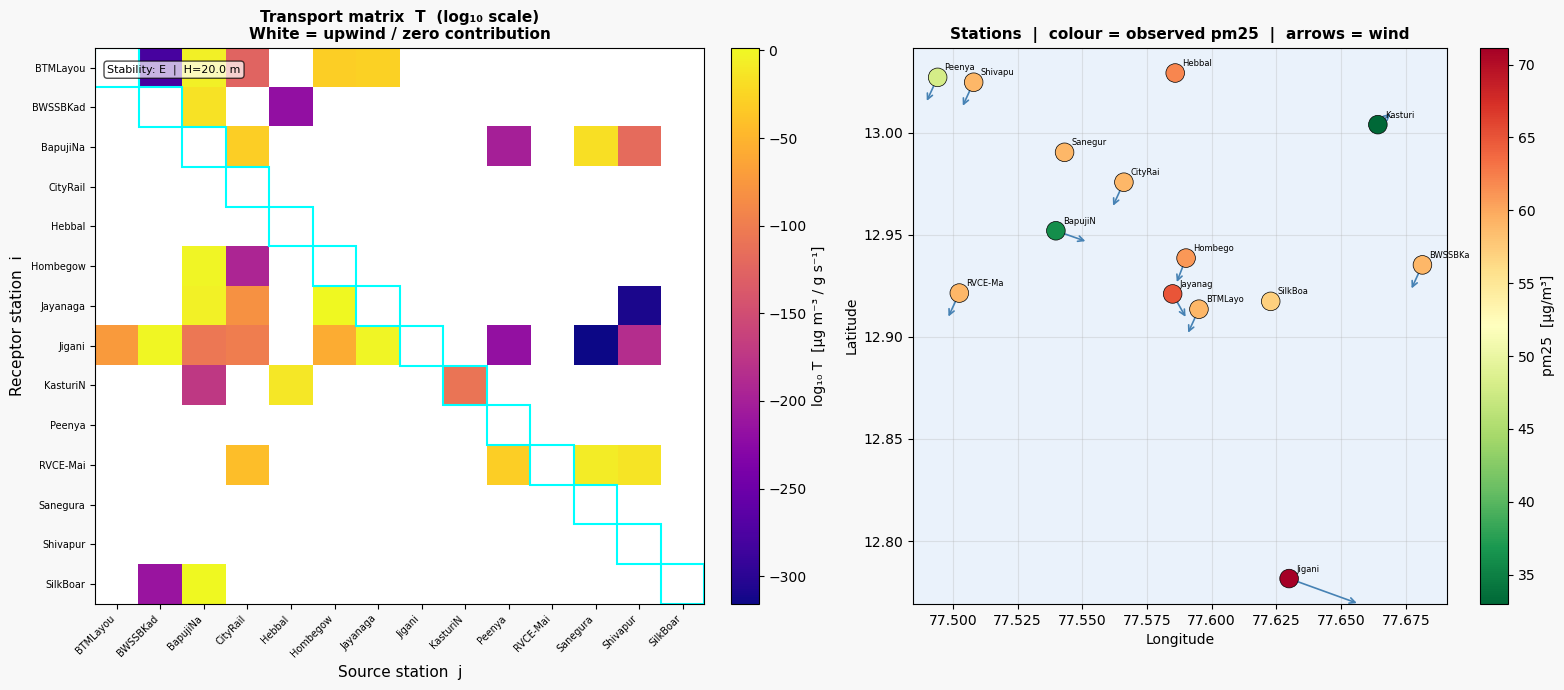

In [12]:
# Block 5 — FIGURE 1 : Transport matrix heatmap + station map
fig1, axes = plt.subplots(1, 2, figsize=(16, 7))
fig1.patch.set_facecolor("#f8f8f8")

# -- Left: T matrix heatmap --
ax = axes[0]
T_log = np.log10(np.where(T_matrix > 0, T_matrix, np.nan))
im = ax.imshow(T_log, cmap="plasma", aspect="auto")
cbar = fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log₁₀ T  [µg m⁻³ / g s⁻¹]", fontsize=10)

short = [s[:8] for s in STATION_NAMES]
ax.set_xticks(range(N))
ax.set_xticklabels(short, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(N))
ax.set_yticklabels(short, fontsize=7)
ax.set_xlabel("Source station  j", fontsize=11)
ax.set_ylabel("Receptor station  i", fontsize=11)
ax.set_title(
    "Transport matrix  T  (log₁₀ scale)\nWhite = upwind / zero contribution",
    fontsize=11,
    fontweight="bold",
)
# Annotate diagonal
for k in range(N):
    ax.add_patch(
        plt.Rectangle((k - 0.5, k - 0.5), 1, 1, fill=False, edgecolor="cyan", lw=1.5)
    )
ax.text(
    0.02,
    0.97,
    f"Stability: {stab_mode}  |  H={H_STACK} m",
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
)
# -- Right: station map with wind arrows --
ax2 = axes[1]
sc = ax2.scatter(
    lons,
    lats,
    c=C_obs,
    cmap="RdYlGn_r",
    s=180,
    zorder=5,
    edgecolors="k",
    linewidths=0.5,
    norm=Normalize(vmin=C_obs.min(), vmax=C_obs.max()),
)
fig1.colorbar(sc, ax=ax2, label=f"{POLLUTANT}  [µg/m³]")
# Wind arrows (one per station, scaled by speed)
for k in range(N):
    wd_rad = np.radians(WD[k])
    dx = np.sin(wd_rad) * 0.012 * (WS[k] / WS.mean())
    dy = np.cos(wd_rad) * 0.012 * (WS[k] / WS.mean())
    ax2.annotate(
        "",
        xy=(lons[k] + dx, lats[k] + dy),
        xytext=(lons[k], lats[k]),
        arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.2),
    )

for k, s in enumerate(STATION_NAMES):
    ax2.annotate(
        s[:7], (lons[k], lats[k]), textcoords="offset points", xytext=(5, 5), fontsize=6
    )
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title(
    f"Stations  |  colour = observed {POLLUTANT}  |  arrows = wind",
    fontsize=11,
    fontweight="bold",
)
ax2.set_facecolor("#eaf2fb")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig1.savefig("fig1_T_matrix_and_map.png", dpi=150, bbox_inches="tight")
print("  Saved: fig1_T_matrix_and_map.png")
plt.show()


In [13]:
T_matrix

array([[ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.0077,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.0001,  0.    ,  0.    , 34.6959,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],

In [14]:
# Print wind directions to verify physical plausibility
print("Wind directions at stations:")
for i, s in enumerate(STATION_NAMES):
    print(f"{s:30s}: {WD[i]:6.1f}°")

Wind directions at stations:
BTMLayout                     :  200.0°
BWSSBKadabesanahalli          :  200.0°
BapujiNagar                   :  114.0°
CityRailwayStation            :  200.0°
Hebbal                        :   97.0°
HombegowdaNagar               :  197.0°
Jayanagar5thBlock             :  156.0°
Jigani                        :  114.6°
KasturiNagar                  :   42.5°
Peenya                        :  200.0°
RVCE-Mailasandra              :  200.0°
SaneguravaHalli               :  200.0°
Shivapura_Peenya              :  200.0°
SilkBoard                     :  125.0°


In [23]:
import networkx as nx

# Create directed graph of transport
G = nx.DiGraph()
for i, rec in enumerate(STATION_NAMES):
    for j, src in enumerate(STATION_NAMES):
        if i != j:
            G.add_edge(src, rec, weight=T_matrix[i, j])

print(f"\nTransport edges: {G.number_of_edges()}")
print("Edges (source → receptor):")
for u, v, data in G.edges(data=True):
    print(f"  {u} → {v}: {data['weight']:.4f}")


Transport edges: 182
Edges (source → receptor):
  BWSSBKadabesanahalli → BTMLayout: 0.0000
  BWSSBKadabesanahalli → BapujiNagar: 0.0000
  BWSSBKadabesanahalli → CityRailwayStation: 0.0000
  BWSSBKadabesanahalli → Hebbal: 0.0000
  BWSSBKadabesanahalli → HombegowdaNagar: 0.0000
  BWSSBKadabesanahalli → Jayanagar5thBlock: 0.0000
  BWSSBKadabesanahalli → Jigani: 1.4892
  BWSSBKadabesanahalli → KasturiNagar: 0.0000
  BWSSBKadabesanahalli → Peenya: 0.0000
  BWSSBKadabesanahalli → RVCE-Mailasandra: 0.0000
  BWSSBKadabesanahalli → SaneguravaHalli: 0.0000
  BWSSBKadabesanahalli → Shivapura_Peenya: 0.0000
  BWSSBKadabesanahalli → SilkBoard: 0.0000
  BTMLayout → BWSSBKadabesanahalli: 0.0000
  BTMLayout → BapujiNagar: 0.0000
  BTMLayout → CityRailwayStation: 0.0000
  BTMLayout → Hebbal: 0.0000
  BTMLayout → HombegowdaNagar: 0.0000
  BTMLayout → Jayanagar5thBlock: 0.0000
  BTMLayout → Jigani: 0.0000
  BTMLayout → KasturiNagar: 0.0000
  BTMLayout → Peenya: 0.0000
  BTMLayout → RVCE-Mailasandra: 0.0

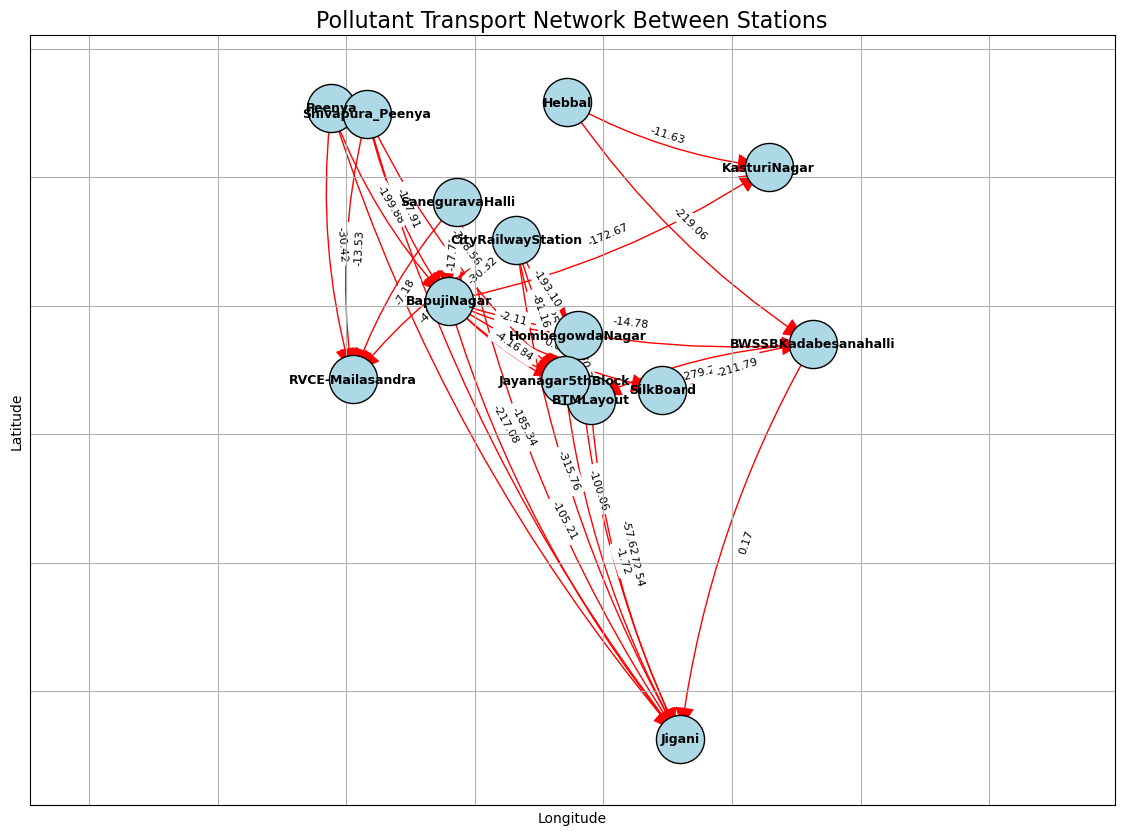

In [33]:
import matplotlib.pyplot as plt
import networkx as nx
import math

# Create position dictionary from lat/lon
pos = {}
for _, row in stations_df.iterrows():
    station = row["StationName"]
    # longitude -> x-axis
    # latitude  -> y-axis
    pos[station] = (row["Longitude"], row["Latitude"])

# Draw figure
plt.figure(figsize=(14, 10))
# Draw nodes
nx.draw_networkx_nodes(
    G, pos, node_size=1200, node_color="lightblue", edgecolors="black"
)
# Draw labels
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
# Draw directed edges
red_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 0]
dotted_edges = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] == 0]

# 2. Draw the active transport paths (Red, Solid)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=red_edges,
    edge_color="red",
    style="solid",
    arrows=True,
    arrowsize=30,
    width=1,
    connectionstyle="arc3,rad=0.1",
)

# 3. Draw the zero-transport paths (Gray, Dotted)
# nx.draw_networkx_edges(
#     G,
#     pos,
#     edgelist=dotted_edges,
#     edge_color="gray",
#     style="dotted",
#     arrows=False,          # Turning off arrows for 0-weight makes it cleaner
#     width=1,
#     connectionstyle="arc3,rad=0.1",
# )
# Edge labels (transport weights)
# Edge labels: Filter for weight > 0 and calculate log10(weight)
edge_labels = {
    (u, v): f"{math.log10(d['weight']):.2f}" 
    for u, v, d in G.edges(data=True) 
    if d['weight'] > 0
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

# Final formatting
plt.title("Pollutant Transport Network Between Stations", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.axis("equal")
plt.show()

# The Atmospheric Inverse Problem: Deconstructing $C = T \cdot Q$

In atmospheric science, tracing pollutants back to their origin requires shifting from a **forward simulation** (predicting dispersion from known stacks) to an **inverse simulation** (estimating unknown emission sources using sensor observations).

---

## 1. Mathematical Formulation

Let the monitoring network consist of $r$ discrete receptor locations (sensors) and $s$ potential emission sources. The steady-state relationship is governed by the linear system:

$$\mathbf{C} = \mathbf{T} \cdot \mathbf{Q}$$

### Vector and Matrix Dimensions

* **The Observation Vector ($\mathbf{C} \in \mathbb{R}^{r \times 1}$):**
A column vector containing the measured mass concentrations ($\mu\text{g/m}^3$) at each receptor $i$.

$$\mathbf{C} = \begin{bmatrix} C_1 \\ C_2 \\ \vdots \\ C_r \end{bmatrix}$$


* **The Source Emission Vector ($\mathbf{Q} \in \mathbb{R}^{s \times 1}$):**
A column vector containing the unknown mass emission rates ($\text{g/s}$) for each source $j$.

$$\mathbf{Q} = \begin{bmatrix} Q_1 \\ Q_2 \\ \vdots \\ Q_s \end{bmatrix}$$


* **The Atmospheric Transport Matrix ($\mathbf{T} \in \mathbb{R}^{r \times s}$):**
A sensitivity matrix where each element $T_{ij}$ represents the dilution physics between source $j$ and receptor $i$.
$$\mathbf{T} = \begin{bmatrix}
T_{11} & T_{12} & \dots & T_{1s} \
T_{21} & T_{22} & \dots & T_{2s} \
\vdots & \vdots & \ddots & \vdots \
T_{r1} & T_{r2} & \dots & T_{rs}
\end{bmatrix}$$

> **Physical Interpretation:** Element $T_{ij}$ defines the concentration impact observed at receptor $i$ if source $j$ emits at an absolute rate of exactly $1\text{ g/s}$.

---

## 2. Why Direct Inversion Fails (Ill-Conditioning)

We cannot simply calculate $\mathbf{Q} = \mathbf{T}^{-1}\mathbf{C}$. The system matrix $\mathbf{T}$ is highly **ill-conditioned**, meaning its condition number is exceptionally large:

$$\kappa(\mathbf{T}) = \frac{\sigma_{\max}}{\sigma_{\min}} \gg 1$$

This severe numerical instability stems from five distinct physical and geometric factors:

* **Upwind Dead Zones:** If a sensor $i$ sits upwind of source $j$, the element $T_{ij}$ is identically $0$. This generates rows filled with near-zero coefficients, compressing the rank of the matrix.
* **Scale Divergence:** Transport couplings decrease exponentially with downwind distance. Elements in $\mathbf{T}$ span multiple orders of magnitude, pairing giant values (near-field receptors) with microscopic decimals (far-field receptors).
* **Atmospheric Anisotropy:** Prevailing wind directions break spatial symmetry. Receptors aligned along the core wind vector register massive sensitivity signals, while crosswind receptors register nothing.
* **Dimensional Mismatch:** The monitoring framework is rarely perfectly square ($r \neq s$). An over-determined system ($r > s$) lacks an exact algebraic solution, while an under-determined system ($r < s$) contains infinite valid solutions.
* **Noise Amplification:** Environmental observations contain sensor noise and background fluctuations ($\mathbf{C}_{\text{obs}} = \mathbf{C} + \boldsymbol{\epsilon}$). Directly inverting an ill-conditioned matrix multiplies this tiny error vector $\boldsymbol{\epsilon}$, causing the calculated values in $\mathbf{Q}$ to oscillate wildly into unphysical domains.

---

## 3. Mathematical Inversion Paradigms

### Method A: Unconstrained Least Squares

When the system has more sensors than sources ($r > s$), we look for an optimal compromise by minimizing the residual $L_2$ norm:

$$\hat{\mathbf{Q}} = \arg\min_{\mathbf{Q}} \left\| \mathbf{C} - \mathbf{T}\mathbf{Q} \right\|^2$$

* **Limitation:** This method ignores physical boundaries. Because of measurement noise and calculation instability, it frequently outputs negative emission values ($\hat{Q}_j < 0$), which are physically impossible for physical smokestacks.

### Method B: Non-Negative Least Squares (NNLS)

To enforce physical consistency, we introduce a strict inequality constraint:

$$\hat{\mathbf{Q}} = \arg\min_{\mathbf{Q}} \left\| \mathbf{C} - \mathbf{T}\mathbf{Q} \right\|^2 \quad \text{subject to} \quad \mathbf{Q} \ge 0$$

* **Mechanism:** This turns the linear problem into an optimization task solved via active-set or interior-point algorithms, forcing impossible negative source elements to zero.

### Method C: Tikhonov Regularization (Ridge Regression)

To combat numerical instability, Tikhonov regularization stabilizes the inversion by adding a penalty term to the objective function. This suppresses unnaturally large values in $\mathbf{Q}$:

$$\hat{\mathbf{Q}} = \arg\min_{\mathbf{Q}} \left( \left\| \mathbf{C} - \mathbf{T}\mathbf{Q} \right\|^2 + \lambda \left\| \mathbf{Q} \right\|^2 \right)$$

The scalar $\lambda > 0$ controls the balance between matching the observation data and keeping the solution smooth.

#### The Regularized Normal Equations

Taking the gradient with respect to $\mathbf{Q}$ and setting it to zero yields the regularized normal equations:

$$(\mathbf{T}^T\mathbf{T} + \lambda \mathbf{I}_s)\hat{\mathbf{Q}} = \mathbf{T}^T\mathbf{C}$$

Where $\mathbf{I}_s$ is an $s \times s$ identity matrix. Adding $\lambda \mathbf{I}_s$ shifts the eigenvalues of the system away from zero, making the matrix invertible even if $\mathbf{T}^T\mathbf{T}$ is singular.

#### Closed-Form Solution

$$\hat{\mathbf{Q}} = (\mathbf{T}^T\mathbf{T} + \lambda \mathbf{I}_s)^{-1}\mathbf{T}^T\mathbf{C}$$

---

## 4. Spectral Decomposition & Truncated SVD

To see exactly how regularizations protect the model from noise, we decompose the transport matrix using **Singular Value Decomposition (SVD)**:

$$\mathbf{T} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$$

### Structural Component Dimensions

* $\mathbf{U} \in \mathbb{R}^{r \times r}$ is an orthogonal matrix whose columns represent the left singular vectors (spatial patterns across the receptors).
* $\mathbf{V} \in \mathbb{R}^{s \times s}$ is an orthogonal matrix whose columns represent the right singular vectors (spatial patterns across the emission sources).
* $\boldsymbol{\Sigma} \in \mathbb{R}^{r \times s}$ is a diagonal matrix containing sorted singular values: $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_{\min} \ge 0$.

### The Moore-Penrose Pseudoinverse Danger

The standard pseudoinverse $\mathbf{T}^{+}$ maps the solution as:

$$\mathbf{T}^{+} = \mathbf{V}\boldsymbol{\Sigma}^{+}\mathbf{U}^T \implies \hat{\mathbf{Q}} = \sum_{k=1}^{\min(r,s)} \frac{\mathbf{u}_k^T \mathbf{C}}{\sigma_k} \mathbf{v}_k$$

> **The Root of Instability:** If a singular value $\sigma_k$ is very small, its reciprocal $\frac{1}{\sigma_k}$ blows up toward infinity. Any high-frequency measurement noise projected onto that vector $\mathbf{u}_k$ completely takes over the solution.

### The Truncated SVD Solution

To prevent this blow-up, Truncated SVD discards weak singular modes below a chosen index threshold $k = k_{\text{trunc}}$:

$$\boldsymbol{\Sigma}_{\mathrm{trunc}}^{+} = \operatorname{diag}\left(\frac{1}{\sigma_1}, \frac{1}{\sigma_2}, \dots, \frac{1}{\sigma_{k_{\text{trunc}}}}, 0, \dots, 0\right)$$

$$\hat{\mathbf{Q}}_{\mathrm{trunc}} = \mathbf{V}\boldsymbol{\Sigma}_{\mathrm{trunc}}^{+}\mathbf{U}^T\mathbf{C}$$

This hard truncation filters out the high-frequency numerical noise, preserving the core stability of the inversion at the cost of smoothing out fine spatial details.

In [23]:
from scipy.optimize import nnls
from scipy.linalg import lstsq, svd

In [25]:
# Block 7 — CLASSICAL SOLVERS
Q_lstsq, res_lstsq, rank_lstsq, sv_lstsq = lstsq(T_matrix, C_obs)
print("[Method 1]  scipy.linalg.lstsq  (minimum-norm least squares)")
print(f"Matrix rank: {rank_lstsq}")
print(f"Singular values range: {sv_lstsq.min():.4f} - {sv_lstsq.max():.4f}")
print(f"Condition number κ(T) = σ_max/σ_min = {sv_lstsq.max() / sv_lstsq.min():.2f}")
print(f"Negative Q entries: {(Q_lstsq < 0).sum()}  (physically invalid)")

#  7.2  Non-negative least squares
Q_nnls, res_nnls = nnls(T_matrix, C_obs)
print("[Method 2]  scipy.optimize.nnls  (non-negative constraint)")
print(f"Residual norm ||C - T·Q||: {res_nnls:.4f}")
print(f"Negative Q entries: {(Q_nnls < 0).sum()}  ✓")
print(f"Zero Q entries    : {(Q_nnls == 0).sum()}  (stations with no attribution)")


#  7.3  Tikhonov regularisation
def tikhonov(T, C, lam):
    """
    Ridge-regularised inversion:
        Q̂ = (TᵀT + λI)⁻¹ Tᵀ C
    """
    n = T.shape[1]
    A = T.T @ T + lam * np.eye(n)
    b = T.T @ C
    return np.linalg.solve(A, b)


LAMBDA = 1.0  # regularisation strength; tune via L-curve or cross-validation
Q_tikh = tikhonov(T_matrix, C_obs, LAMBDA)
print(f"[Method 3]  Tikhonov regularisation  (λ = {LAMBDA})")
print(f"  ||C - T·Q||: {np.linalg.norm(C_obs - T_matrix @ Q_tikh):.4f}")
print(f"  Negative Q entries: {(Q_tikh < 0).sum()}")


#  7.4  Truncated SVD
def truncated_svd_solve(T, C, n_components=None, thresh_ratio=1e-3):
    """
    Solve C = T·Q via pseudoinverse with small singular values zeroed out.
    thresh_ratio: singular values < thresh_ratio * σ_max are zeroed.
    """
    U, s, Vt = svd(T, full_matrices=False)
    thresh = thresh_ratio * s[0]
    s_inv = np.where(s > thresh, 1.0 / s, 0.0)
    return Vt.T @ (s_inv * (U.T @ C))


Q_svd = truncated_svd_solve(T_matrix, C_obs, thresh_ratio=1e-3)
print("[Method 4]  Truncated SVD  (threshold ratio = 1e-3)")
print(f"||C - T·Q||: {np.linalg.norm(C_obs - T_matrix @ Q_svd):.4f}")
print(f"Negative Q entries: {(Q_svd < 0).sum()}")

#  7.5  Comparison table
methods = ["lstsq", "NNLS", "Tikhonov", "TruncSVD"]
Q_all = [Q_lstsq, Q_nnls, Q_tikh, Q_svd]

df_Q = pd.DataFrame({m: Q for m, Q in zip(methods, Q_all)}, index=STATION_NAMES)
df_Q["C_obs"] = C_obs
df_Q["C_lstsq"] = T_matrix @ Q_lstsq
df_Q["C_nnls"] = T_matrix @ Q_nnls
if Q_true is not None:
    df_Q["Q_true"] = Q_true

print("Inferred Q per station (g/s):")
print(df_Q[methods].round(4).to_string())

print("Residuals  ||C - TQ||  per method:")
for m, Q in zip(methods, Q_all):
    r = np.linalg.norm(C_obs - T_matrix @ Q)
    print(f"    {m:12s}: {r:.4f}")


[Method 1]  scipy.linalg.lstsq  (minimum-norm least squares)
Matrix rank: 5
Singular values range: 0.0000 - 34.6959
Condition number κ(T) = σ_max/σ_min = inf
Negative Q entries: 1  (physically invalid)
[Method 2]  scipy.optimize.nnls  (non-negative constraint)
Residual norm ||C - T·Q||: 165.0903
Negative Q entries: 0  ✓
Zero Q entries    : 8  (stations with no attribution)
[Method 3]  Tikhonov regularisation  (λ = 1.0)
  ||C - T·Q||: 183.3448
  Negative Q entries: 0
[Method 4]  Truncated SVD  (threshold ratio = 1e-3)
||C - T·Q||: 181.9894
Negative Q entries: 1


/tmp/ipykernel_5118/307346973.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Condition number κ(T) = σ_max/σ_min = {sv_lstsq.max() / sv_lstsq.min():.2f}")
/tmp/ipykernel_5118/307346973.py:44: RuntimeWarning: divide by zero encountered in divide
  s_inv = np.where(s > thresh, 1.0 / s, 0.0)


NameError: name 'Q_true' is not defined

In [ ]:
# Block 8 — FIGURE 2: Classical solver comparison
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))
fig2.patch.set_facecolor("#f8f8f8")
fig2.suptitle(
    "Classical Solvers — Emission Rate Attribution  Q  [g/s]",
    fontsize=14,
    fontweight="bold",
)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
x_ticks = np.arange(N)

# -- Panel A: Q per method --
ax = axes2[0, 0]
width = 0.2
for k, (m, Q, col) in enumerate(zip(methods, Q_all, colors)):
    ax.bar(x_ticks + k * width, Q, width, label=m, color=col, alpha=0.85)
if Q_true is not None:
    ax.step(
        x_ticks + 0.3,
        Q_true,
        where="mid",
        color="black",
        lw=2,
        linestyle="--",
        label="Q_true (synthetic)",
    )
ax.set_xticks(x_ticks + width)
ax.set_xticklabels([s[:8] for s in STATION_NAMES], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Emission rate  Q  [g/s]")
ax.set_title("A  |  Inferred Q per station")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# -- Panel B: Observed vs Reconstructed C --
ax = axes2[0, 1]
ax.plot(C_obs, "ko-", label="C_obs", lw=1.5, ms=5)
for m, Q, col in zip(methods, Q_all, colors):
    ax.plot(T_matrix @ Q, "^--", color=col, label=f"T·Q ({m})", lw=1, ms=4, alpha=0.8)
ax.set_xticks(x_ticks)
ax.set_xticklabels([s[:8] for s in STATION_NAMES], rotation=45, ha="right", fontsize=7)
ax.set_ylabel(f"{POLLUTANT}  [µg/m³]")
ax.set_title("B  |  Observed vs Reconstructed  C")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# -- Panel C: Singular value spectrum --
ax = axes2[1, 0]
U, s_vals, Vt = svd(T_matrix)
ax.semilogy(range(1, len(s_vals) + 1), s_vals, "bo-", ms=6)
ax.axhline(
    s_vals[0] * 1e-3, color="red", ls="--", label="Truncation threshold (1e-3 x σ₁)"
)
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value  σ_k  (log scale)")
ax.set_title("C  |  SVD spectrum of T\n(indicates ill-conditioning)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.text(
    0.98,
    0.95,
    f"κ(T) = {s_vals[0] / s_vals[-1]:.1f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", fc="wheat", alpha=0.8),
)

# -- Panel D: L-curve (Tikhonov) --
ax = axes2[1, 1]
lambdas = np.logspace(-4, 4, 80)
resid_n = []
sol_n = []
for lv in lambdas:
    Qv = tikhonov(T_matrix, C_obs, lv)
    resid_n.append(np.log10(np.linalg.norm(C_obs - T_matrix @ Qv) + 1e-12))
    sol_n.append(np.log10(np.linalg.norm(Qv) + 1e-12))

ax.plot(resid_n, sol_n, "b-o", ms=3, lw=1)
# Highlight λ = LAMBDA
best_idx = np.argmin(np.abs(np.array(lambdas) - LAMBDA))
ax.plot(resid_n[best_idx], sol_n[best_idx], "r*", ms=14, label=f"λ={LAMBDA}")
ax.set_xlabel("log₁₀ ||C - TQ||  (residual norm)")
ax.set_ylabel("log₁₀ ||Q||  (solution norm)")
ax.set_title("D  |  L-curve (Tikhonov)\nCorner = optimal λ")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.text(
    0.02,
    0.98,
    "← Regularised\nUnderfitting →",
    transform=ax.transAxes,
    va="top",
    fontsize=8,
    color="gray",
)

plt.tight_layout()
fig2.savefig("fig2_classical_solvers.png", dpi=150, bbox_inches="tight")
print("  Saved: fig2_classical_solvers.png")
plt.show()

In [ ]:
# Block 9 — SYMPY: BAYESIAN INFERENCE (prior, likelihood, posterior)
print("\n Block 9 : Bayesian inference — symbolic derivation ")

Q_i = symbols("Q_i", positive=True)
mu_0 = symbols("mu_0", positive=True)  # prior mean
sigma_prior = symbols("sigma_0", positive=True)
sigma_obs = symbols("sigma_C", positive=True)
C_i, T_i = symbols("C_i T_i", positive=True)

# Prior: Q_i ~ LogNormal(mu_0, sigma_0)  → because Q_i > 0 always
# log Q_i ~ Normal(mu_0, sigma_0²)
log_prior = (
    -((sp.ln(Q_i) - mu_0) ** 2) / (2 * sigma_prior**2)
    - sp.ln(Q_i)
    - sp.ln(sigma_prior)
    - sp.ln(sp.sqrt(2 * pi))
)
print("  [Eq 11]  Prior on emission rates — LogNormal:")
print(r"  Q_i ~ LogNormal(μ₀, σ₀²)")
print(r"  log p(Q_i) ∝ -(log Q_i - μ₀)² / (2σ₀²) - log Q_i")

# Likelihood: C ~ Normal(T·Q, sigma_obs²) per station
log_lik = (
    -((C_i - T_i * Q_i) ** 2) / (2 * sigma_obs**2)
    - sp.log(sigma_obs)
    - sp.log(sp.sqrt(2 * pi))
)
print("  [Eq 12]  Likelihood — Gaussian observation noise:")
print(r"  C_i | Q, T ~ Normal(Σ_j T_{ij} Q_j , σ_C²)")
print(r"  log L ∝ -(C_i - T_i · Q_i)² / (2σ_C²)")

# Posterior (Bayes' theorem):
print("  [Eq 13]  Posterior (Bayes' theorem):")
print(r"  log p(Q | C) ∝ log p(C | Q) + log p(Q)")
print("  With a LogNormal prior this does NOT have a closed-form posterior,")
print("  so we use MCMC (No-U-Turn Sampler in PyMC) to sample from p(Q | C).")
print("  [Eq 14]  Advantages of the Bayesian approach:")
print("    • Full posterior distribution → uncertainty bounds on each Q_i")
print("    • Physical constraints (Q > 0) are built into the prior")
print("    • Can incorporate domain knowledge (e.g. known emission inventories)")
print("    • Model comparison via WAIC / LOO-CV")

In [ ]:
# Block 10 — BAYESIAN INFERENCE WITH PyMC
import pymc as pm
import pytensor.tensor as pt

# Normalise T and C to improve sampler geometry
# (PyMC samples more efficiently when variables are O(1))
T_scale = T_matrix.max()
C_scale = C_obs.max()
T_norm = T_matrix / T_scale
C_norm = C_obs / C_scale

print(f"  T_scale = {T_scale:.4f}   C_scale = {C_scale:.4f}")
print("  Model:")
print("    Q_i ~ HalfNormal(σ = 2.0)   [all Q ≥ 0 by construction]")
print("    C_pred = T_norm · Q")
print("    σ_obs ~ HalfNormal(0.2)")
print("    C_obs ~ Normal(C_pred, σ_obs)")

with pm.Model() as bayes_model:
    # Prior: HalfNormal enforces Q ≥ 0 without log-transform tricks
    # σ=2 → 95% prior mass in [0, ~3.9] emission units (after rescaling)
    Q_bayes = pm.HalfNormal("Q", sigma=2.0, shape=N)

    # Predicted concentrations (linear model)
    C_pred = pm.math.dot(T_norm, Q_bayes)

    # Observation noise
    sigma_obs_rv = pm.HalfNormal("sigma_obs", sigma=0.2)

    # Likelihood
    C_like = pm.Normal("C_obs", mu=C_pred, sigma=sigma_obs_rv, observed=C_norm)

    # Inference — NUTS sampler
    print("  Sampling with NUTS (2 chains x 1500 draws, 500 tune steps)…")
    trace = pm.sample(
        1500,
        tune=500,
        chains=2,
        cores=1,
        target_accept=0.90,
        progressbar=True,
        return_inferencedata=True,
        random_seed=42,
    )

print("Sampling complete.")

In [ ]:
import arviz as az
# Block 11 — POSTERIOR ANALYSIS

summary = az.summary(trace, var_names=["Q"], round_to=4)
print(summary)

# Rescale back to original units: Q_actual = Q_sampled * C_scale / T_scale
Q_posterior = trace.posterior["Q"].values  # shape: (chain, draw, N)
Q_rescaled = Q_posterior * (C_scale / T_scale)  # g/s (approximate)

Q_mean = Q_rescaled.mean(axis=(0, 1))
Q_lo = np.percentile(Q_rescaled, 5, axis=(0, 1))
Q_hi = np.percentile(Q_rescaled, 95, axis=(0, 1))

print("Posterior Q  [rescaled, approximate g/s]:")
print(f"  {'Station':30s}  {'Mean':>8}  {'5th':>8}  {'95th':>8}")
for i, s in enumerate(STATION_NAMES):
    print(f"  {s:30s}  {Q_mean[i]:8.4f}  {Q_lo[i]:8.4f}  {Q_hi[i]:8.4f}")

In [ ]:
# Block 12 — FIGURE 3 : Bayesian posterior
print("\n Block 12 : Figure 3 — Bayesian posterior ")

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor("#f8f8f8")
fig3.suptitle(
    "Bayesian Inference — Posterior Emission Rates  Q", fontsize=13, fontweight="bold"
)

# -- Left: Posterior mean + credible interval --
ax = axes3[0]
y_pos = np.arange(N)
ax.barh(
    y_pos,
    Q_mean,
    xerr=[Q_mean - Q_lo, Q_hi - Q_mean],
    align="center",
    alpha=0.75,
    color="#4C72B0",
    error_kw=dict(elinewidth=1.5, capsize=4, ecolor="#2c4e80"),
)
if Q_nnls is not None:
    ax.scatter(
        Q_nnls * (C_scale / T_scale),
        y_pos,
        color="red",
        zorder=5,
        s=40,
        marker="D",
        label="NNLS estimate",
    )
if Q_true is not None:
    ax.scatter(Q_true, y_pos, color="black", zorder=6, s=40, marker="*", label="Q_true")
ax.set_yticks(y_pos)
ax.set_yticklabels(STATION_NAMES, fontsize=8)
ax.set_xlabel("Emission rate  Q  [g/s, rescaled]")
ax.set_title("Posterior mean ± 90% CI")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.axvline(0, color="gray", lw=0.8, ls="--")

# -- Right: Posterior violin plots for top-8 stations --
ax2 = axes3[1]
top8_idx = np.argsort(Q_mean)[-8:][::-1]
data_violin = [Q_rescaled[:, :, k].flatten() for k in top8_idx]
labels_v = [STATION_NAMES[k][:10] for k in top8_idx]
parts = ax2.violinplot(
    data_violin, positions=range(len(top8_idx)), showmedians=True, showextrema=False
)
for pc in parts["bodies"]:
    pc.set_facecolor("#4C72B0")
    pc.set_alpha(0.6)
parts["cmedians"].set_color("orange")
parts["cmedians"].set_linewidth(2)
ax2.set_xticks(range(len(top8_idx)))
ax2.set_xticklabels(labels_v, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Emission rate  Q  [g/s, rescaled]")
ax2.set_title("Posterior distribution — top 8 emitters\n(width = uncertainty)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig3.savefig("fig3_bayesian_posterior.png", dpi=150, bbox_inches="tight")
print("  Saved: fig3_bayesian_posterior.png")
plt.show()

In [ ]:
# Block 13 — FIGURE 4 : Attribution stacked bar (explainability)
print("\n Block 13 : Figure 4 — Attribution (explainability) ")

print("  [Eq 15]  Fractional attribution of source j to receptor i:")
print(r"  α_{ij} = T_{ij} · Q_j  /  Σ_k T_{ik} · Q_k")
print("  We compute this for NNLS (deterministic) and Bayesian mean.")
print("  This is the core 'explainability' output: for each monitoring")
print("  station, what fraction of the measured pollution came from each")
print("  other station (as a source)?")


def attribution_matrix(T, Q):
    """
    α[i,j] = T[i,j]*Q[j] / Σ_k T[i,k]*Q[k]
    Shape: (N_receptors, N_sources)
    Returns: raw contribution [µg/m³] and fractional [0-1]
    """
    contrib = T * Q[np.newaxis, :]  # broadcast: (N,N)
    total = contrib.sum(axis=1, keepdims=True)
    total = np.where(total == 0, 1.0, total)
    frac = contrib / total
    return contrib, frac


contrib_nnls, frac_nnls = attribution_matrix(T_matrix, Q_nnls)
Q_bayes_mean_raw = Q_mean / (C_scale / T_scale)  # normalised units for T
contrib_bayes, frac_bayes = attribution_matrix(T_matrix, Q_mean)

# Stacked bar: each receptor's total = 100%, split by source contribution
fig4, axes4 = plt.subplots(2, 1, figsize=(16, 12))
fig4.patch.set_facecolor("#f8f8f8")
fig4.suptitle(
    "Source Attribution  α_{ij}  — Fraction of concentration at each receptor\nfrom each source",
    fontsize=13,
    fontweight="bold",
)

cmap_attr = plt.cm.get_cmap("tab20", N)

for row_idx, (frac, title) in enumerate(
    [(frac_nnls, "NNLS  (deterministic)"), (frac_bayes, "Bayesian  (posterior mean)")]
):
    ax = axes4[row_idx]
    bottom = np.zeros(N)
    for j in range(N):
        vals = frac[:, j] * 100  # percent
        ax.bar(
            range(N),
            vals,
            bottom=bottom,
            color=cmap_attr(j),
            label=STATION_NAMES[j][:10] if row_idx == 0 else "",
            width=0.6,
        )
        # Label cells > 10%
        for i in range(N):
            if vals[i] > 8:
                ax.text(
                    i,
                    bottom[i] + vals[i] / 2,
                    f"{vals[i]:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=6,
                    fontweight="bold",
                    color="white",
                )
        bottom += vals

    ax.set_xticks(range(N))
    ax.set_xticklabels(
        [s[:10] for s in STATION_NAMES], rotation=45, ha="right", fontsize=8
    )
    ax.set_ylabel("% attribution")
    ax.set_ylim(0, 105)
    ax.set_title(f"{title}")
    ax.grid(axis="y", alpha=0.2)
    if row_idx == 0:
        ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=6, ncol=1)

plt.tight_layout()
fig4.savefig("fig4_attribution.png", dpi=150, bbox_inches="tight")
print("  Saved: fig4_attribution.png")
plt.show()


In [ ]:
# Block 14 — TRACE DIAGNOSTICS (R-hat, ESS)
print("\n Block 14 : MCMC diagnostics ")

print("  Convergence criteria:")
print("  • R̂ (Gelman-Rubin) < 1.01  → chains have mixed")
print("  • ESS_bulk > 400           → sufficient effective samples")

diag = az.summary(trace, var_names=["Q"], kind="diagnostics")
print(diag.to_string())

# arviz >= 0.18 changed plot_trace API; use matplotlib directly
Q_post = trace.posterior["Q"].values  # (chain, draw, N)
n_show = min(6, N)
fig_trace, tr_axes = plt.subplots(n_show, 2, figsize=(14, 2.5 * n_show))
fig_trace.suptitle(
    "MCMC Trace plots  —  Q  (normalised units, first 6 params)", fontsize=12
)
for k in range(n_show):
    samples_k = Q_post[:, :, k]  # (chain, draw)
    # -- trace --
    ax_t = tr_axes[k, 0]
    for ch in range(samples_k.shape[0]):
        ax_t.plot(samples_k[ch], lw=0.4, alpha=0.7)
    ax_t.set_ylabel(STATION_NAMES[k][:12], fontsize=7)
    ax_t.tick_params(labelsize=7)
    if k == 0:
        ax_t.set_title("Trace", fontsize=9)
    # -- density --
    ax_d = tr_axes[k, 1]
    for ch in range(samples_k.shape[0]):
        ax_d.hist(samples_k[ch], bins=40, alpha=0.5, density=True)
    ax_d.tick_params(labelsize=7)
    if k == 0:
        ax_d.set_title("Posterior density", fontsize=9)
plt.tight_layout()
plt.savefig("fig5_trace.png", dpi=100, bbox_inches="tight")
print("Saved: fig5_trace.png")
plt.show()